In [1]:
import xarray as xr
from matplotlib import pyplot as plt
plt.style.use('../grl.mplstyle')
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/'
import numpy as np
import xrft

In [2]:
######## Read in ##########
DIR = '/Users/jiarongw/Data/multilayer_data/JPO2024/processed/'
def open (label):
    global DIR
    tlist = np.array([110,130,150,170])
    filelist = [DIR + label + f'/field{t}.nc' for t in tlist]
    ds = xr.open_mfdataset(filelist, concat_dim='t', combine='nested')
    ds = ds.assign_coords(t=tlist)
    return ds

# NL = 15
ds1 = open('C4') 
ds2 = open('C4_NL30')
ds3 = open('C4_NL45')

In [15]:
ds1['eta'] = ds1['h'].sum(dim='zl') - 40

In [17]:
ds = xr.open_dataset(DIR + 'C4/series.nc')

In [18]:
ds

<xarray.Dataset>
Dimensions:  (t: 81, x: 1024, y: 1024)
Coordinates:
  * t        (t) int64 100 101 102 103 104 105 106 ... 175 176 177 178 179 180
  * x        (x) float64 -99.9 -99.71 -99.51 -99.32 ... 99.32 99.51 99.71 99.9
  * y        (y) float64 -99.9 -99.71 -99.51 -99.32 ... 99.32 99.51 99.71 99.9
Data variables:
    eta      (t, x, y) float32 ...
    ux       (t, x, y) float32 ...
    uy       (t, x, y) float32 ...
    ke       (t) float32 ...
    gpe      (t) float32 ...
Attributes:
    sourcepath:  /projects/DEIKE/jiarongw/multilayer/revision/field_new_200m_...
    L:           200
    P:           0.02
    Re:          40000
    LEVEL:       10
    NL:          15
    rand:        2
    Htheta:      0.503
    H:           40.0
    label:       C4

In [49]:
''' Compute wave height distribution from 1D eta. 
    Option of zero-crossing, up-crossing, or down-crossing. '''
    
from scipy.signal import find_peaks
    
def spatial_wave_heights(eta_slice, mode="upcrossing", subtract_mean=True):
    """
    Computes spatial wave heights from a 1D elevation slice using crossing-based definitions.

    Parameters:
        eta_slice (1D array): Surface elevation along space (e.g., η(x) or η(y))
        mode (str): "upcrossing", "downcrossing", or "zerocrossing"
        subtract_mean (bool): Remove mean to center around zero

    Returns:
        heights (list): List of crest-to-trough wave heights between crossings
    """
    if subtract_mean:
        eta_slice = eta_slice - np.mean(eta_slice)

    heights = []
    crossings = []
    
    # For zero-crossing it's different
    if mode == "zerocrossing":
        peaks, _ = find_peaks(eta_slice)
        troughs, _ = find_peaks(-eta_slice)

        # Combine and sort extrema indices
        extrema = np.sort(np.concatenate([peaks, troughs]))
        heights = []

        for i in range(len(extrema) - 1):
            i1 = extrema[i]
            i2 = extrema[i+1]
            segment = eta_slice[i1:i2+1]

            # Check if the segment includes a zero crossing
            if np.any((segment[:-1] * segment[1:]) < 0):  # Sign change
                H = np.max(segment) - np.min(segment)
                heights.append(H)

    # Detect crossing indices based on selected mode
    elif mode == "upcrossing":
        crossings = [i for i in range(1, len(eta_slice))
                     if eta_slice[i-1] < 0 and eta_slice[i] >= 0]

    elif mode == "downcrossing":
        crossings = [i for i in range(1, len(eta_slice))
                     if eta_slice[i-1] > 0 and eta_slice[i] <= 0]

    else:
        raise ValueError("mode must be 'upcrossing', 'downcrossing', or 'zerocrossing'")

    # Measure wave heights between consecutive crossings
    for i in range(len(crossings) - 1):
        start = crossings[i]
        end = crossings[i+1]
        segment = eta_slice[start:end]

        if len(segment) > 0:
            H = np.max(segment) - np.min(segment)
            heights.append(H)

    return heights

In [56]:
eta_slice = ds.eta.isel(t=0, y=10).values
H_up = spatial_wave_heights(eta_slice, mode="upcrossing")
H_down = spatial_wave_heights(eta_slice, mode="downcrossing")
H_all = spatial_wave_heights(eta_slice, mode="zerocrossing")

In [77]:
len(ds.t)

81

In [78]:
H_ups = []
H_downs = []
for t in range(0, 10):
    for i in range(0, 1024, 8):
        H_up = spatial_wave_heights(ds.eta.isel(t=t, y=i).values, mode="upcrossing")
        H_down = spatial_wave_heights(ds.eta.isel(t=t, y=i).values, mode="downcrossing")
        H_ups.extend(H_up)
        H_downs.extend(H_down)
    
# H_ups = np.vstack(H_ups).flatten()
# H_downs = np.vstack(H_downs).flatten()

In [82]:
import numpy as np

# Save H_ups and H_downs as .npy files
np.save('H_ups.npy', np.array(H_ups))
np.save('H_downs.npy', np.array(H_downs))

In [85]:
sigma_est = np.sqrt(np.mean(np.array(H_ups)**2) / 2)

Text(0.5, 0, 'Wave height (m)')

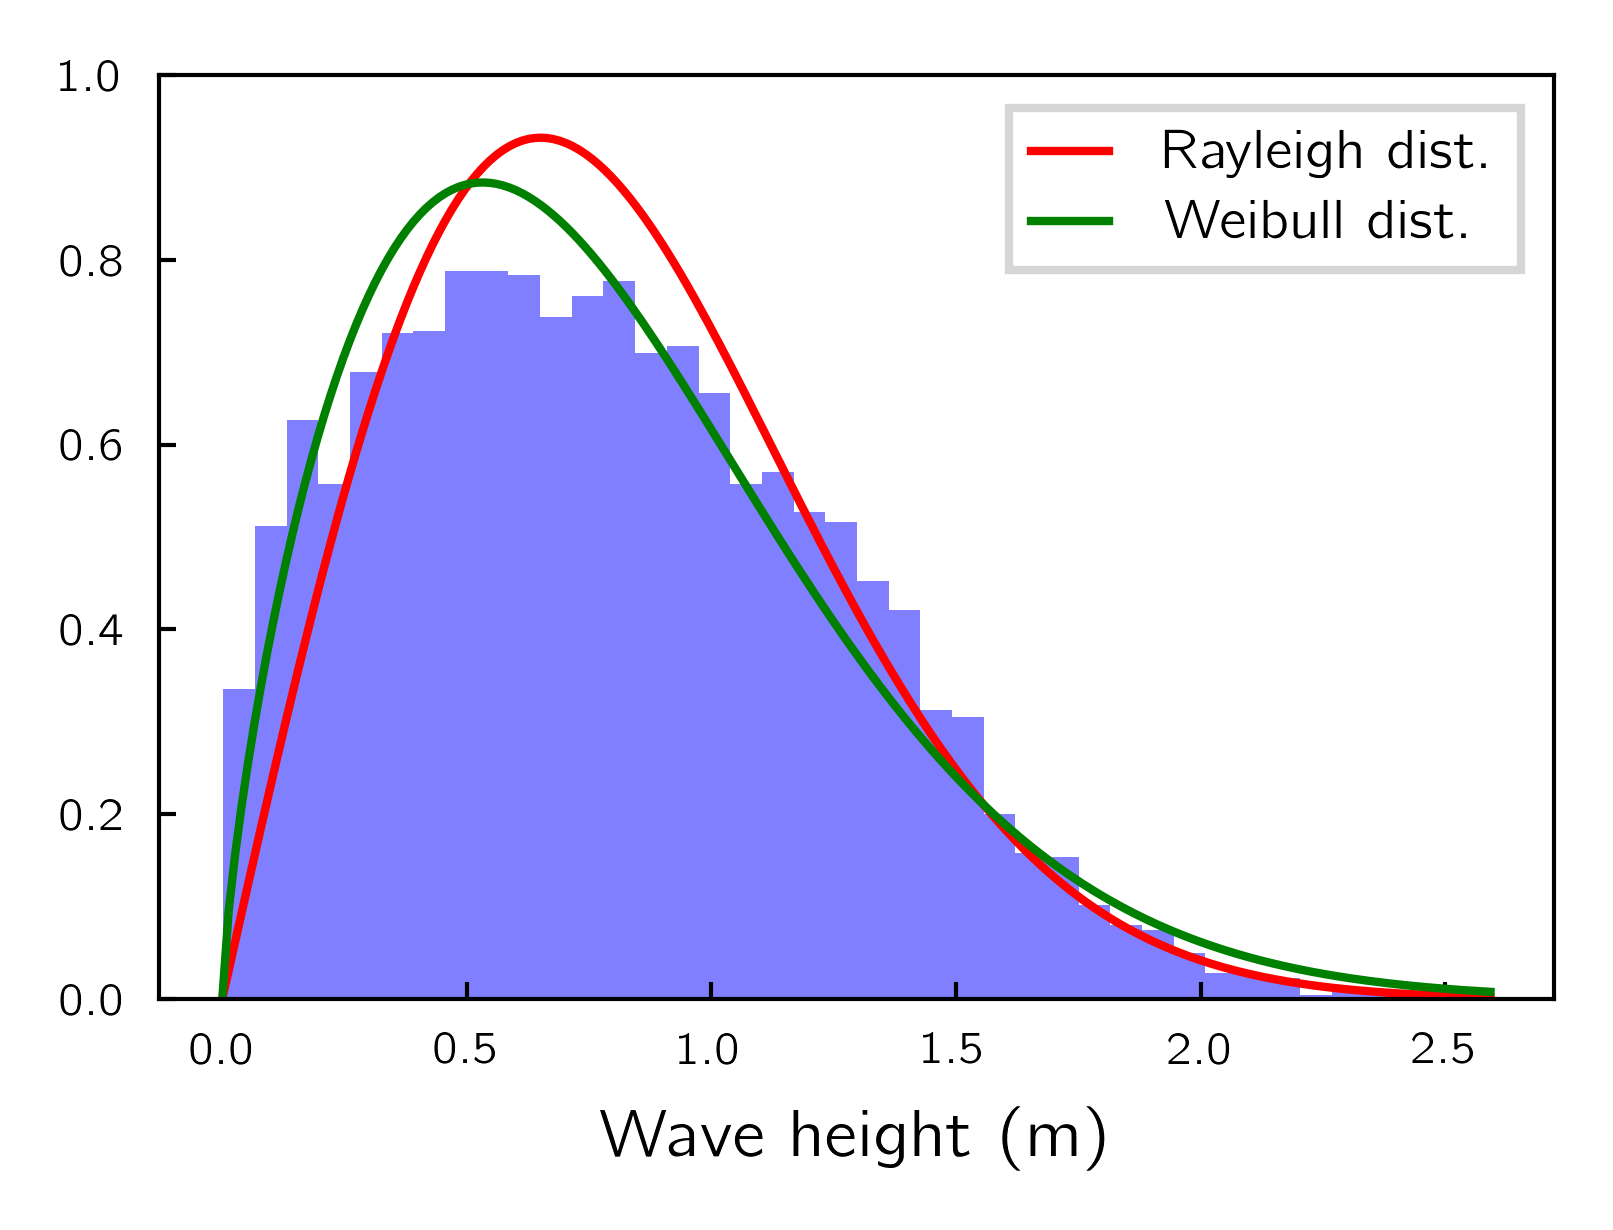

In [98]:
fig = plt.figure(figsize=(3,2))
from scipy.stats import rayleigh
from scipy.stats import weibull_min

# Fit Rayleigh distribution to the data
param = rayleigh.fit(H_ups, floc=0)  # Force location = 0
sigma_hat = param[1] 

# Fit Weibull distribution to the data
shape, loc, scale = weibull_min.fit(H_ups, floc=0)

plt.hist(H_ups, bins=40, density=True, alpha=0.5, color='blue')
# plt.hist(H_downs, bins=40, density=True)
# plt.hist(H_downs, bins=30)

x = np.linspace(0, np.max(H_ups), 200)
pdf = rayleigh.pdf(x, loc=0, scale=sigma_hat)
plt.plot(x, pdf, 'r-', lw=1, label='Rayleigh dist.')

pdf_fit = weibull_min.pdf(x, shape, loc=0, scale=scale)
plt.plot(x, pdf_fit, 'g-', lw=1, label='Weibull dist.')

plt.legend(handletextpad=1.0)
plt.ylim([0, 1])
plt.xlabel('Wave height (m)')


In [101]:
(0.157*9.8)**0.5

1.2404031602668546

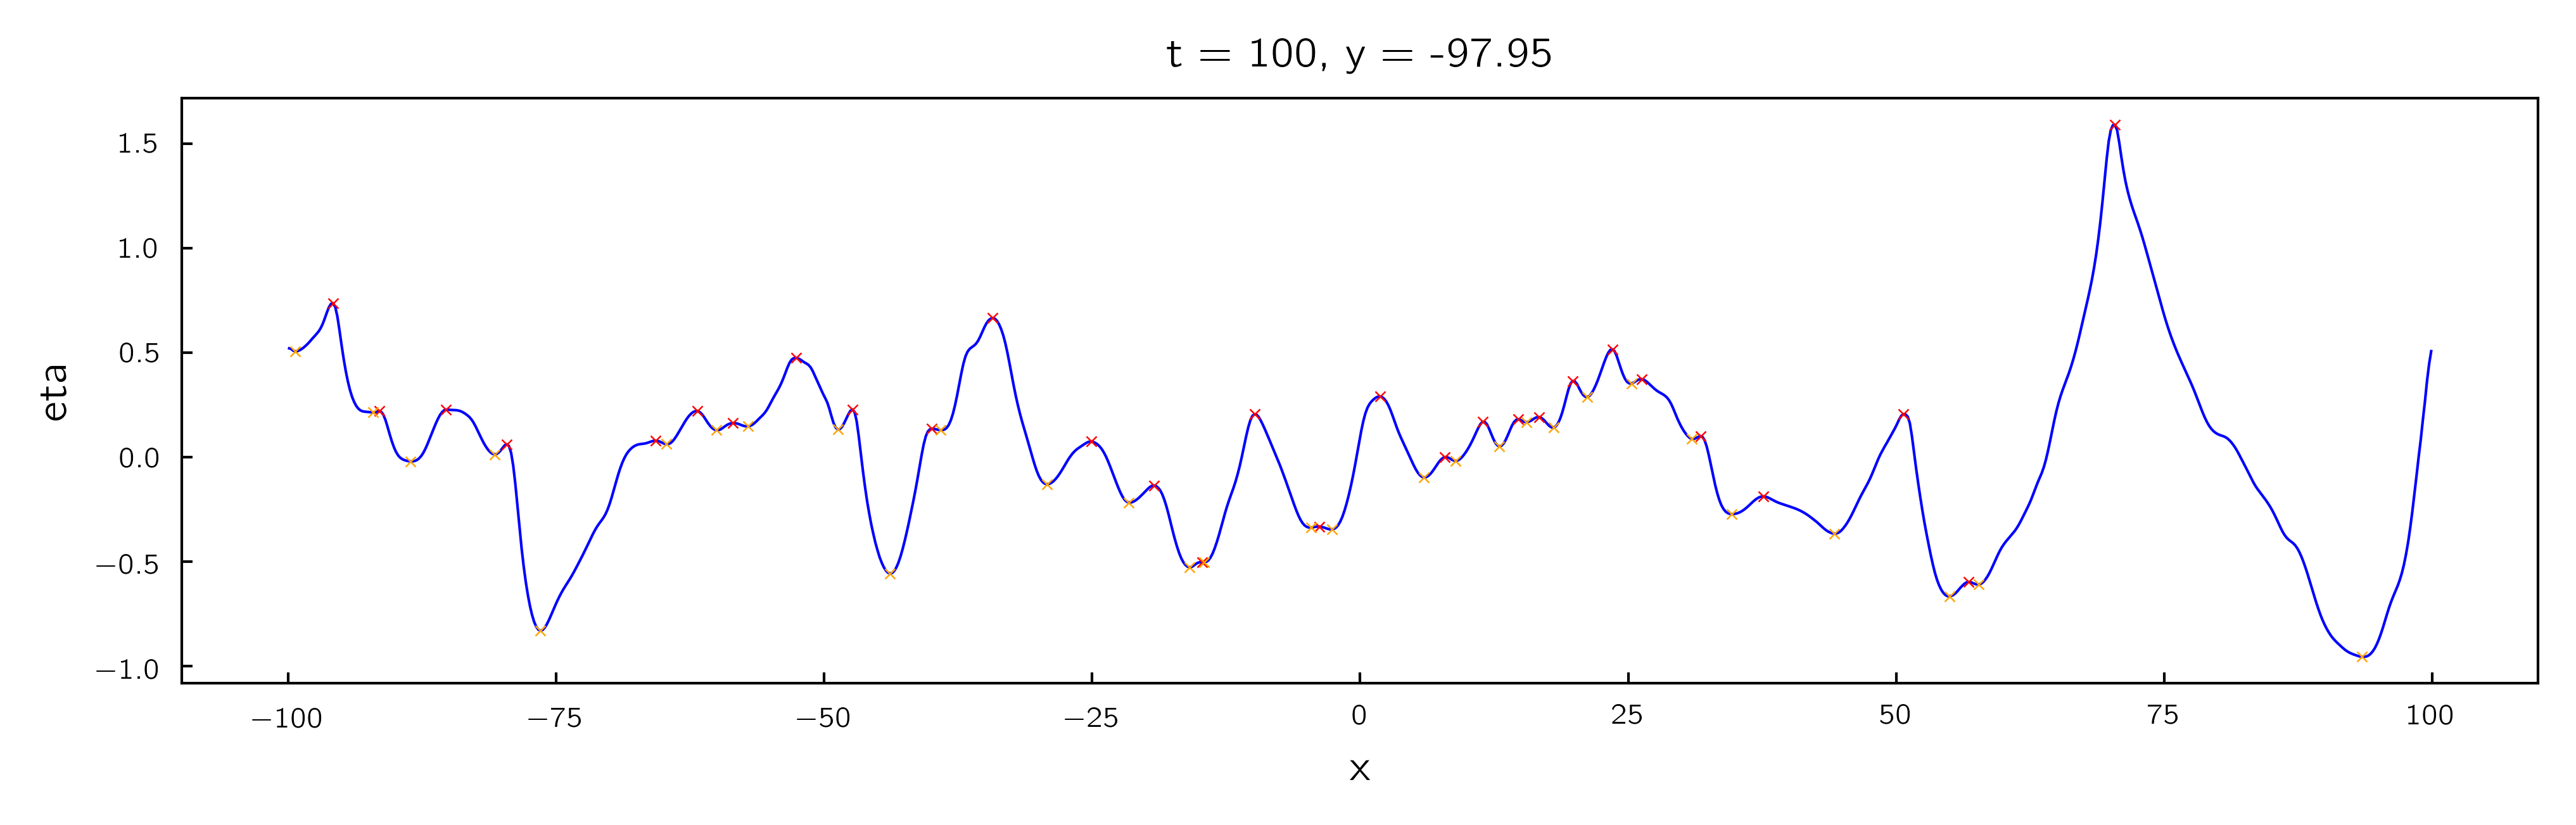

In [ ]:
fig = plt.figure(figsize=[8,2])
ds.eta.isel(t=0, y=10).plot()

from scipy.signal import find_peaks
eta_slice = ds.eta.isel(t=0, y=10).values
peaks, _ = find_peaks(eta_slice)
troughs, _ = find_peaks(-eta_slice)

plt.plot(ds['x'].isel(x=peaks), eta_slice[peaks], "x", color='red', label='peaks')
plt.plot(ds['x'].isel(x=troughs), eta_slice[troughs], "x", color='orange', label='troughs')



In [41]:
heights

[0.24020594,
 0.24745369,
 0.8921356,
 0.9092285,
 0.7841937,
 0.6921599,
 0.79422426,
 0.20431897,
 0.29188183,
 0.70818514,
 0.5421291,
 0.63596475,
 0.38727707,
 0.09745704,
 0.018309107,
 0.18699387,
 0.37343055,
 0.57132757,
 0.87118274,
 2.1970627,
 2.5434482]

In [ ]:
def wave_heights_from_spatial_upcrossings(eta_slice):
    eta_slice = eta_slice - np.mean(eta_slice)  # Remove mean sea level
    upcrossings = []

    for i in range(1, len(eta_slice)):
        if eta_slice[i-1] < 0 and eta_slice[i] >= 0:
            upcrossings.append(i)

    heights = []
    for i in range(len(upcrossings) - 1):
        start = upcrossings[i]
        end = upcrossings[i+1]
        segment = eta_slice[start:end]
        if len(segment) > 0:
            H = np.max(segment) - np.min(segment)
            heights.append(H)

    return heights

In [27]:
from scipy.signal import find_peaks
from scipy.ndimage import maximum_filter, minimum_filter


eta = ds.eta.isel(t=0).values
crest = (eta == maximum_filter(eta, size=10))

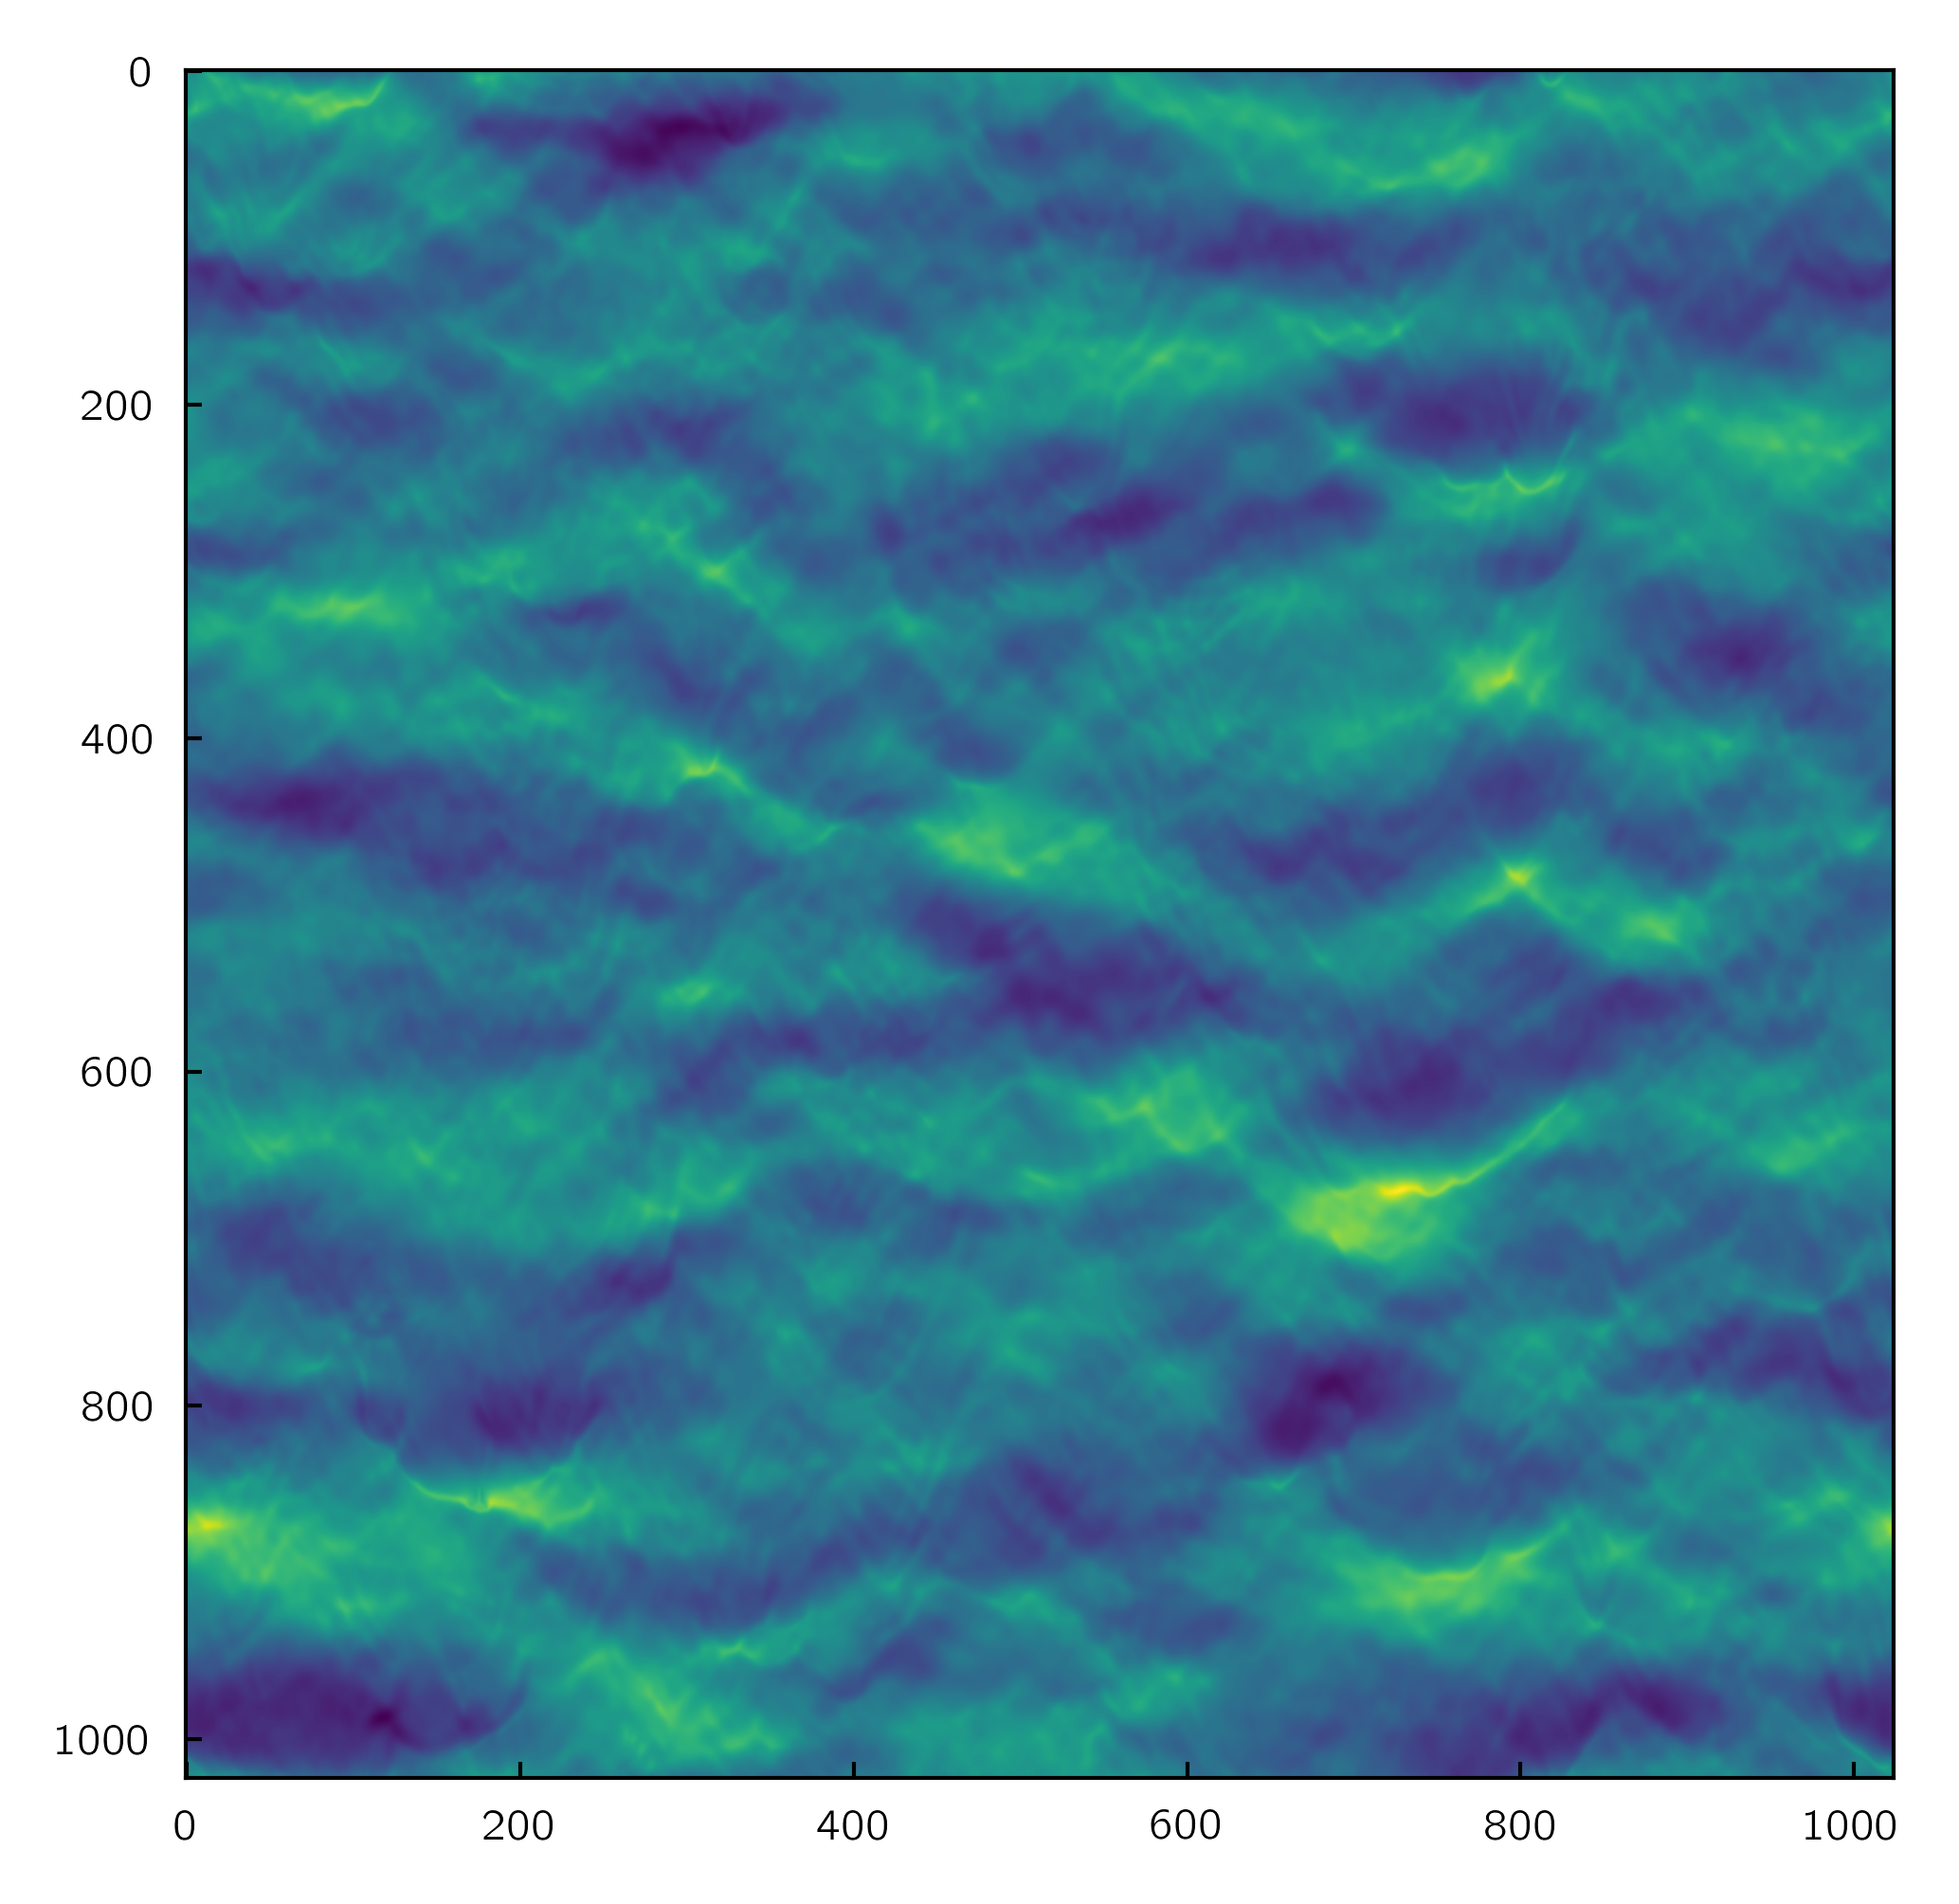

In [28]:
import numpy as np
from scipy.signal import find_peaks

def wave_heights_with_zero_crossing(eta_slice):
    peaks, _ = find_peaks(eta_slice)
    troughs, _ = find_peaks(-eta_slice)

    # Combine and sort extrema indices
    extrema = np.sort(np.concatenate([peaks, troughs]))
    heights = []

    for i in range(len(extrema) - 1):
        i1 = extrema[i]
        i2 = extrema[i+1]
        segment = eta_slice[i1:i2+1]

        # Check if the segment includes a zero crossing
        if np.any((segment[:-1] * segment[1:]) < 0):  # Sign change
            H = np.max(segment) - np.min(segment)
            heights.append(H)

    return heights


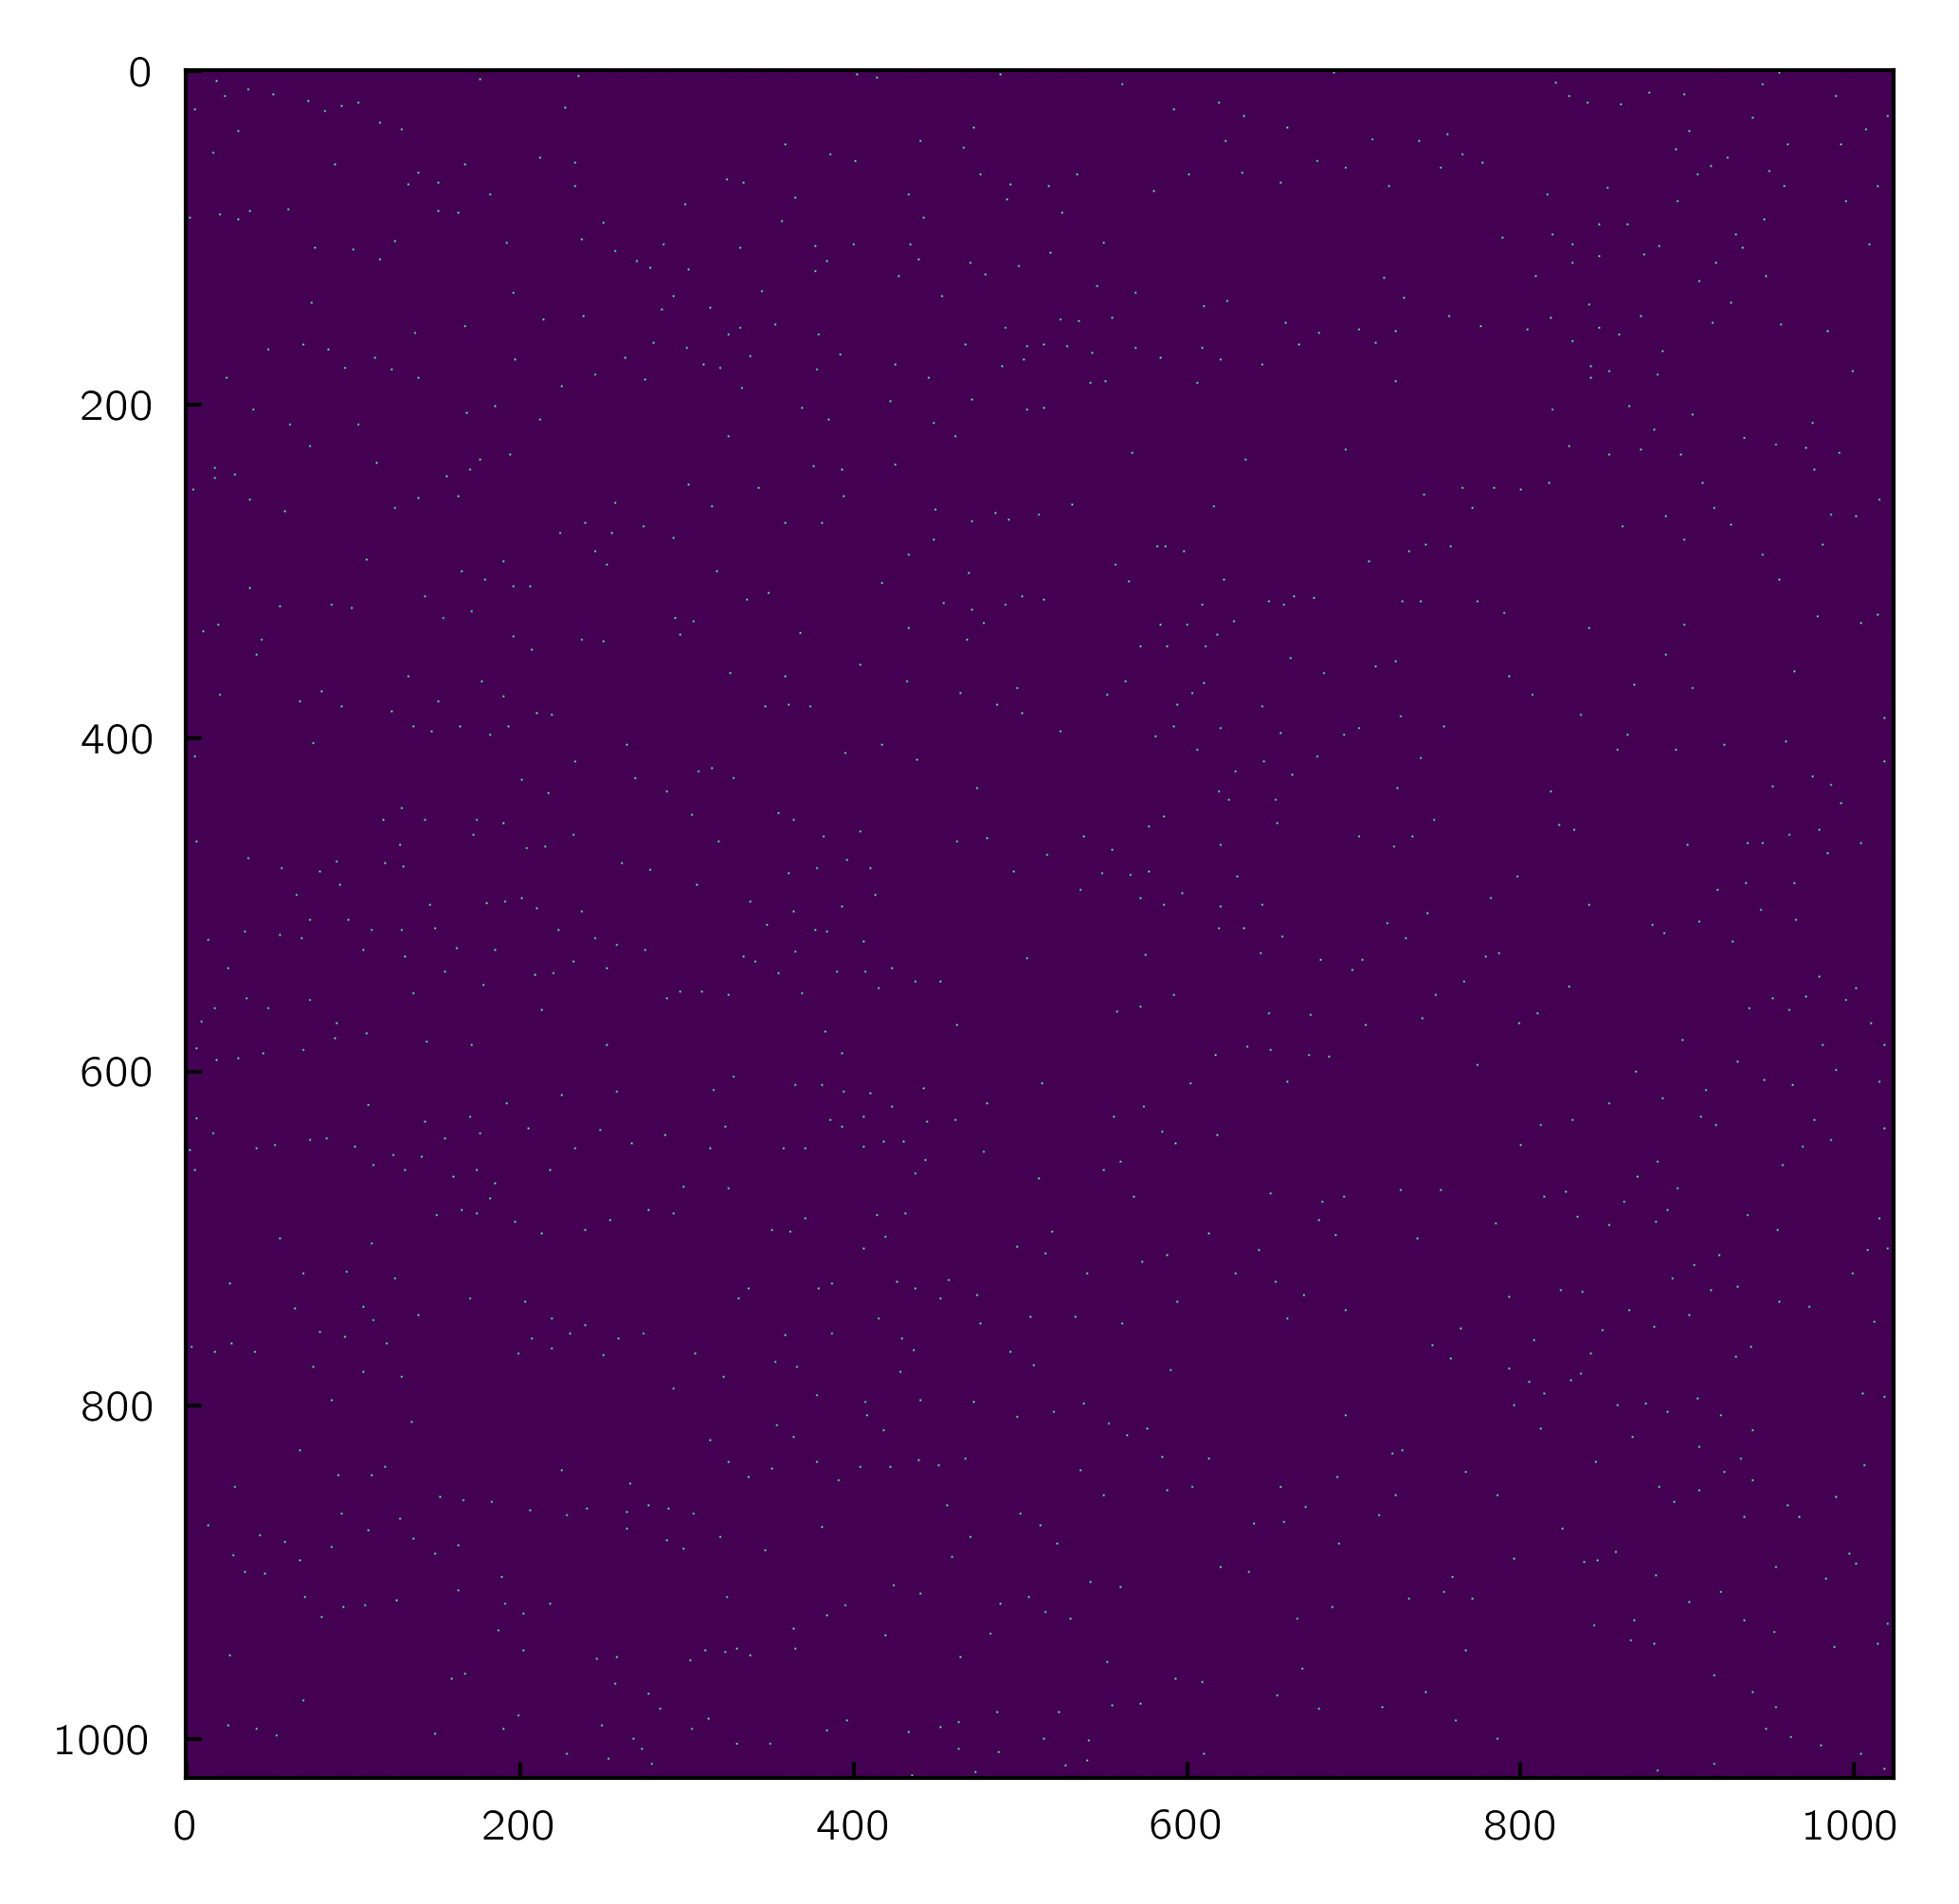

In [30]:
plt.imshow(crest)